In [1]:
import torch
import torchvision
from torchvision.transforms import v2

In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size=4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

100%|██████████| 170M/170M [23:28<00:00, 121kB/s]


In [8]:
classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

In [14]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(3,6,5)
    self.conv2=nn.Conv2d(6,16,5)
    self.fc1=nn.Linear(16*5*5,120)
    self.fc2=nn.Linear(120,84)
    self.fc3=nn.Linear(84,10)


  def forward(self,input):
    c1=F.relu(self.conv1(input))
    s2=F.max_pool2d(c1,(2,2))
    c3=F.relu(self.conv2(s2))
    s4=F.max_pool2d(c3,2)
    s4=torch.flatten(s4,1)
    f5=F.relu(self.fc1(s4))
    f6=F.relu(self.fc2(f5))
    output=self.fc3(f6)
    return output


net=Net()
print(net)


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [15]:
params=list(net.parameters())
print(len(params))
print(params[0].size())


10
torch.Size([6, 3, 5, 5])


In [18]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001)

In [21]:
for epoch in range(5):
  running_loss=0.0
  for i,data in enumerate(trainloader,0):
    inputs,labels=data
    optimizer=optim.SGD(net.parameters(),lr=0.01)
    optimizer.zero_grad()
    output=net(inputs)
    loss=criterion(output,labels)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    if i % 2000 == 1999:
      print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
      running_loss = 0.0




[1,  2000] loss: 2.152
[1,  4000] loss: 1.834
[1,  6000] loss: 1.672
[1,  8000] loss: 1.592
[1, 10000] loss: 1.500
[1, 12000] loss: 1.473
[2,  2000] loss: 1.403
[2,  4000] loss: 1.411
[2,  6000] loss: 1.353
[2,  8000] loss: 1.322
[2, 10000] loss: 1.314
[2, 12000] loss: 1.287
[3,  2000] loss: 1.221
[3,  4000] loss: 1.220
[3,  6000] loss: 1.214
[3,  8000] loss: 1.213
[3, 10000] loss: 1.194
[3, 12000] loss: 1.196
[4,  2000] loss: 1.116
[4,  4000] loss: 1.111
[4,  6000] loss: 1.112
[4,  8000] loss: 1.134
[4, 10000] loss: 1.115
[4, 12000] loss: 1.113
[5,  2000] loss: 1.025
[5,  4000] loss: 1.035
[5,  6000] loss: 1.044
[5,  8000] loss: 1.046
[5, 10000] loss: 1.062
[5, 12000] loss: 1.061


In [ ]:
class BasicBlock(nn.Module):
  expansion=1

  def __init__()





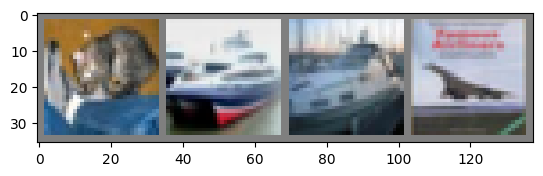

GroundTruth:  cat   ship  ship  plane


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


In [23]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 60 %
